In [2]:
import pandas as pd
import numpy as np

# Carga
df = pd.read_csv("../../data/processed/weather_processed.csv")

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

# Configuración de gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

# Calidad de datos

Antes de realizar el análisis exploratorio, se evaluó la calidad general del dataset mediante la detección de:

- valores faltantes,
- registros duplicados,
- y posibles problemas estructurales.

## Valores faltantes

Se identificó la presencia de valores faltantes principalmente en variables relacionadas con:

- humedad,
- presión atmosférica,
- y punto de rocío.

La proporción de valores ausentes no resulta despreciable, por lo que este aspecto deberá considerarse posteriormente durante la etapa de preprocessing y modelado.

Dado el contexto climático del problema, los valores faltantes podrían estar asociados a:

- fallos de sensores,
- registros incompletos,
- o dificultades operativas en estaciones meteorológicas.

## Registros duplicados

No se detectaron registros completamente duplicados dentro del dataset procesado.

Esto sugiere que el proceso de cleaning previo eliminó correctamente redundancias estructurales en los datos.

In [2]:
df.isnull().sum().sort_values(ascending=False)

ASLP         372
ASTP         372
ADPT         367
AWBT         367
RHMN         365
RHMX         365
RHAV         365
WSF5          10
WDF5          10
WDF2           8
AWND           8
WSF2           8
TMAX           0
TMIN           0
Rain           0
month          0
dayofweek      0
month_sin      0
month_cos      0
dtype: int64

In [3]:
df.duplicated().sum()

np.int64(0)

# Distribución de la variable objetivo

Antes de iniciar el modelado, se analizó la distribución de la variable objetivo (`Rain`) con el fin de evaluar el balance entre clases.

## Balance de clases

El dataset presenta una mayor proporción de días sin lluvia (`Rain = 0`) respecto a días lluviosos (`Rain = 1`).

Sin embargo, el desbalance observado no resulta extremo, ya que ambas clases mantienen una representación significativa dentro del conjunto de datos.

## Implicancias para modelado

Aunque el nivel de desbalance no parece suficiente como para requerir técnicas agresivas de resampling, este aspecto continúa siendo relevante para la evaluación del modelo.

Por este motivo, durante la etapa de Machine Learning se priorizarán:

- validación estratificada (`StratifiedKFold`),
- métricas robustas para clasificación binaria,
- y evaluación más allá de accuracy.

Entre las métricas consideradas se incluyen:

- Precision,
- Recall,
- F1-score,
- y ROC-AUC.

Esto permitirá evaluar correctamente la capacidad del modelo para detectar eventos de lluvia dentro de un contexto climático realista.

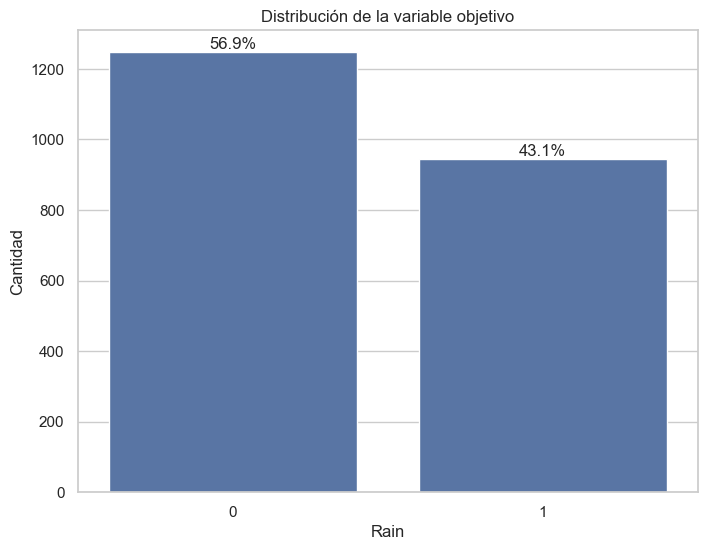

In [3]:
plt.figure(figsize=(8,6))

ax = sns.countplot(
    data=df,
    x='Rain'
)

total = len(df)

for p in ax.patches:
    
    percentage = f'{100 * p.get_height()/total:.1f}%'
    
    x = p.get_x() + p.get_width()/2
    y = p.get_height()
    
    ax.annotate(
        percentage,
        (x, y),
        ha='center',
        va='bottom'
    )

plt.title('Distribución de la variable objetivo')

plt.xlabel('Rain')
plt.ylabel('Cantidad')

plt.show()

In [7]:
(df['Rain'].value_counts(normalize=True) * 100).round(2)

Rain
0    56.89
1    43.11
Name: proportion, dtype: float64

# Análisis de correlación y reducción de redundancia

Luego de realizar una exploración inicial del dataset, se construyó una matriz de correlación con el objetivo de comprender las relaciones lineales entre variables meteorológicas y detectar posibles redundancias dentro del sistema.

Este análisis permite identificar:

- grupos de variables altamente correlacionadas,
- relaciones coherentes desde el punto de vista climático,
- posibles problemas de multicolinealidad,
- y variables potencialmente relevantes para la predicción de lluvia.

## Redundancia entre variables

Se observaron fuertes correlaciones entre distintas familias de variables meteorológicas:

### Variables térmicas

Las variables relacionadas con temperatura y humedad atmosférica (`TMAX`, `TMIN`, `ADPT`, `AWBT`) presentan correlaciones elevadas entre sí, indicando que describen aspectos similares del estado térmico de la atmósfera.

### Variables de humedad

Las variables `RHAV`, `RHMN` y `RHMX` muestran alta correlación, lo cual resulta esperable debido a que representan diferentes medidas de humedad relativa.

### Variables de presión atmosférica

`ASLP` y `ASTP` presentan una correlación prácticamente perfecta, sugiriendo que ambas contienen información muy similar.

### Variables de viento

Las velocidades de viento (`WSF2`, `WSF5`) y las direcciones (`WDF2`, `WDF5`) también evidencian relaciones importantes.

## Objetivo del análisis

A partir de esta etapa, el EDA deja de enfocarse en una exploración masiva de todas las variables y pasa a priorizar un subconjunto representativo de features relevantes.

Esto permite:

- reducir ruido visual,
- evitar gráficos redundantes,
- mejorar interpretabilidad,
- y construir un análisis más enfocado en la capacidad predictiva del sistema climático.

## Relación con la variable objetivo

Las variables asociadas con humedad, presión atmosférica y temperatura húmeda muestran relaciones relevantes con la ocurrencia de lluvia, lo cual coincide con el comportamiento esperado desde el punto de vista meteorológico.

Este tipo de coherencia entre los datos y el fenómeno físico fortalece la interpretabilidad del modelo y aporta confianza sobre la calidad del dataset procesado.

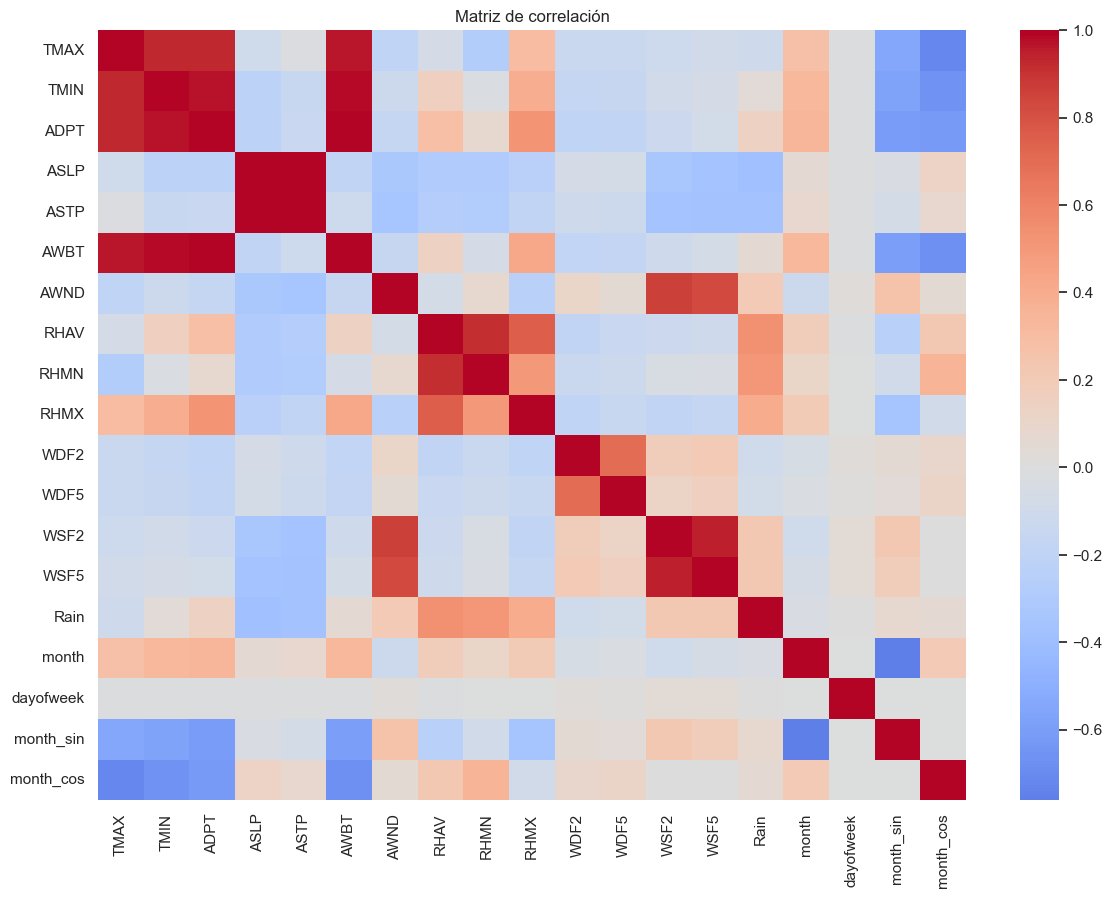

In [17]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de correlación')

plt.show()

# Selección de variables para análisis visual

Luego del análisis de correlación y de la relación entre las variables y la variable objetivo (`Rain`), se seleccionó un subconjunto reducido de features para los análisis visuales posteriores.

El objetivo de esta selección es construir un EDA más interpretativo y menos redundante, evitando generar múltiples gráficos que aporten información repetida debido a la alta correlación entre variables meteorológicas similares.

## Criterios utilizados

La selección de variables se realizó considerando:

- correlación con la variable objetivo,
- redundancia entre features,
- interpretabilidad meteorológica,
- y representatividad dentro de cada grupo de variables.

## Variables seleccionadas

| Variable | Justificación |
|---|---|
| `TMAX` | Representa el comportamiento térmico general |
| `ADPT` | Relacionada con humedad atmosférica y punto de rocío |
| `ASLP` | Indicador importante de presión atmosférica |
| `RHAV` | Medida general de humedad relativa |
| `RHMX` | Complementa el comportamiento de humedad extrema |
| `AWND` | Velocidad promedio del viento |
| `WSF5` | Representa eventos de ráfagas máximas |
| `month` | Permite analizar estacionalidad |
| `Rain` | Variable objetivo |

## Variables excluidas del análisis visual profundo

Algunas variables fueron excluidas de los gráficos posteriores debido a su fuerte correlación con otras features ya seleccionadas.

Por ejemplo:

- `ASTP` presenta correlación casi perfecta con `ASLP`,
- `RHMN` resulta altamente redundante respecto a `RHAV` y `RHMX`,
- `WSF2` contiene información similar a `WSF5`,
- y varias variables térmicas muestran relaciones lineales muy fuertes entre sí.

Esto no implica necesariamente que dichas variables sean eliminadas del modelado posterior, sino únicamente que no aportan información visual adicional relevante dentro del EDA.

## Objetivo de esta reducción

Reducir el conjunto de variables visualizadas permite:

- mejorar la claridad del análisis,
- facilitar la interpretación de patrones climáticos,
- evitar sobrecarga visual,
- y construir un EDA más alineado con objetivos de Machine Learning y selección de features.

In [18]:
corr_target = corr['Rain'].sort_values(ascending=False)

corr_target

Rain         1.000000
RHAV         0.543377
RHMN         0.508832
RHMX         0.406498
WSF5         0.223717
WSF2         0.223530
AWND         0.208569
ADPT         0.137580
month_sin    0.074562
AWBT         0.063569
month_cos    0.057943
TMIN         0.036285
dayofweek    0.003884
month       -0.038513
WDF5        -0.086704
WDF2        -0.096245
TMAX        -0.105846
ASTP        -0.366511
ASLP        -0.384438
Name: Rain, dtype: float64

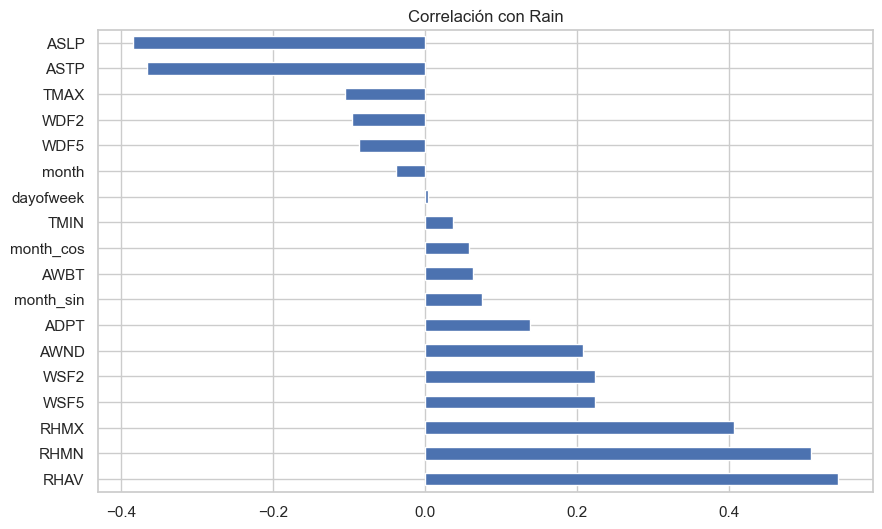

In [19]:
corr_target.drop('Rain').plot(
    kind='barh'
)

plt.title('Correlación con Rain')

plt.show()

In [9]:
selected_features = [
    'TMAX',
    'ADPT',
    'ASLP',
    'RHAV',
    'RHMX',
    'AWND',
    'WSF5',
    'month',
    'Rain'
]

# Distribución de variables seleccionadas

Luego de reducir la redundancia entre variables, se analizaron las distribuciones de las features meteorológicas más representativas del sistema.

El objetivo de esta etapa es comprender:

- comportamiento estadístico de las variables,
- presencia de asimetrías,
- posibles outliers,
- y patrones climáticos relevantes para modelado predictivo.

## Variables atmosféricas

La presión atmosférica (`ASLP`) presenta una distribución aproximadamente normal y relativamente estable, lo cual resulta coherente con el comportamiento esperado de variables barométricas.

Por otro lado, variables asociadas al viento (`AWND`, `WSF5`) exhiben distribuciones sesgadas con colas hacia la derecha, reflejando la ocurrencia poco frecuente de eventos extremos de viento.

## Variables de humedad

Las variables relacionadas con humedad (`RHAV`, `RHMX`) muestran una fuerte concentración en valores elevados, comportamiento consistente con condiciones favorables para eventos de precipitación.

## Variables térmicas

Las distribuciones de temperatura y punto de rocío (`TMAX`, `ADPT`) sugieren posibles comportamientos multimodales, lo cual podría estar asociado a cambios estacionales o diferentes regímenes climáticos presentes en el dataset.

## Implicancias para Machine Learning

El análisis de distribuciones permite anticipar varios aspectos relevantes para modelado:

- presencia de variables asimétricas,
- existencia de eventos extremos reales,
- posibles diferencias estacionales,
- y necesidad de utilizar estrategias robustas de imputación y escalado.

Además, estos patrones sugieren que modelos capaces de capturar relaciones no lineales podrían adaptarse mejor al comportamiento climático observado.

In [10]:
numeric_cols = df[selected_features].select_dtypes(include=np.number).columns

numeric_cols

Index(['TMAX', 'ADPT', 'ASLP', 'RHAV', 'RHMX', 'AWND', 'WSF5', 'month',
       'Rain'],
      dtype='object')

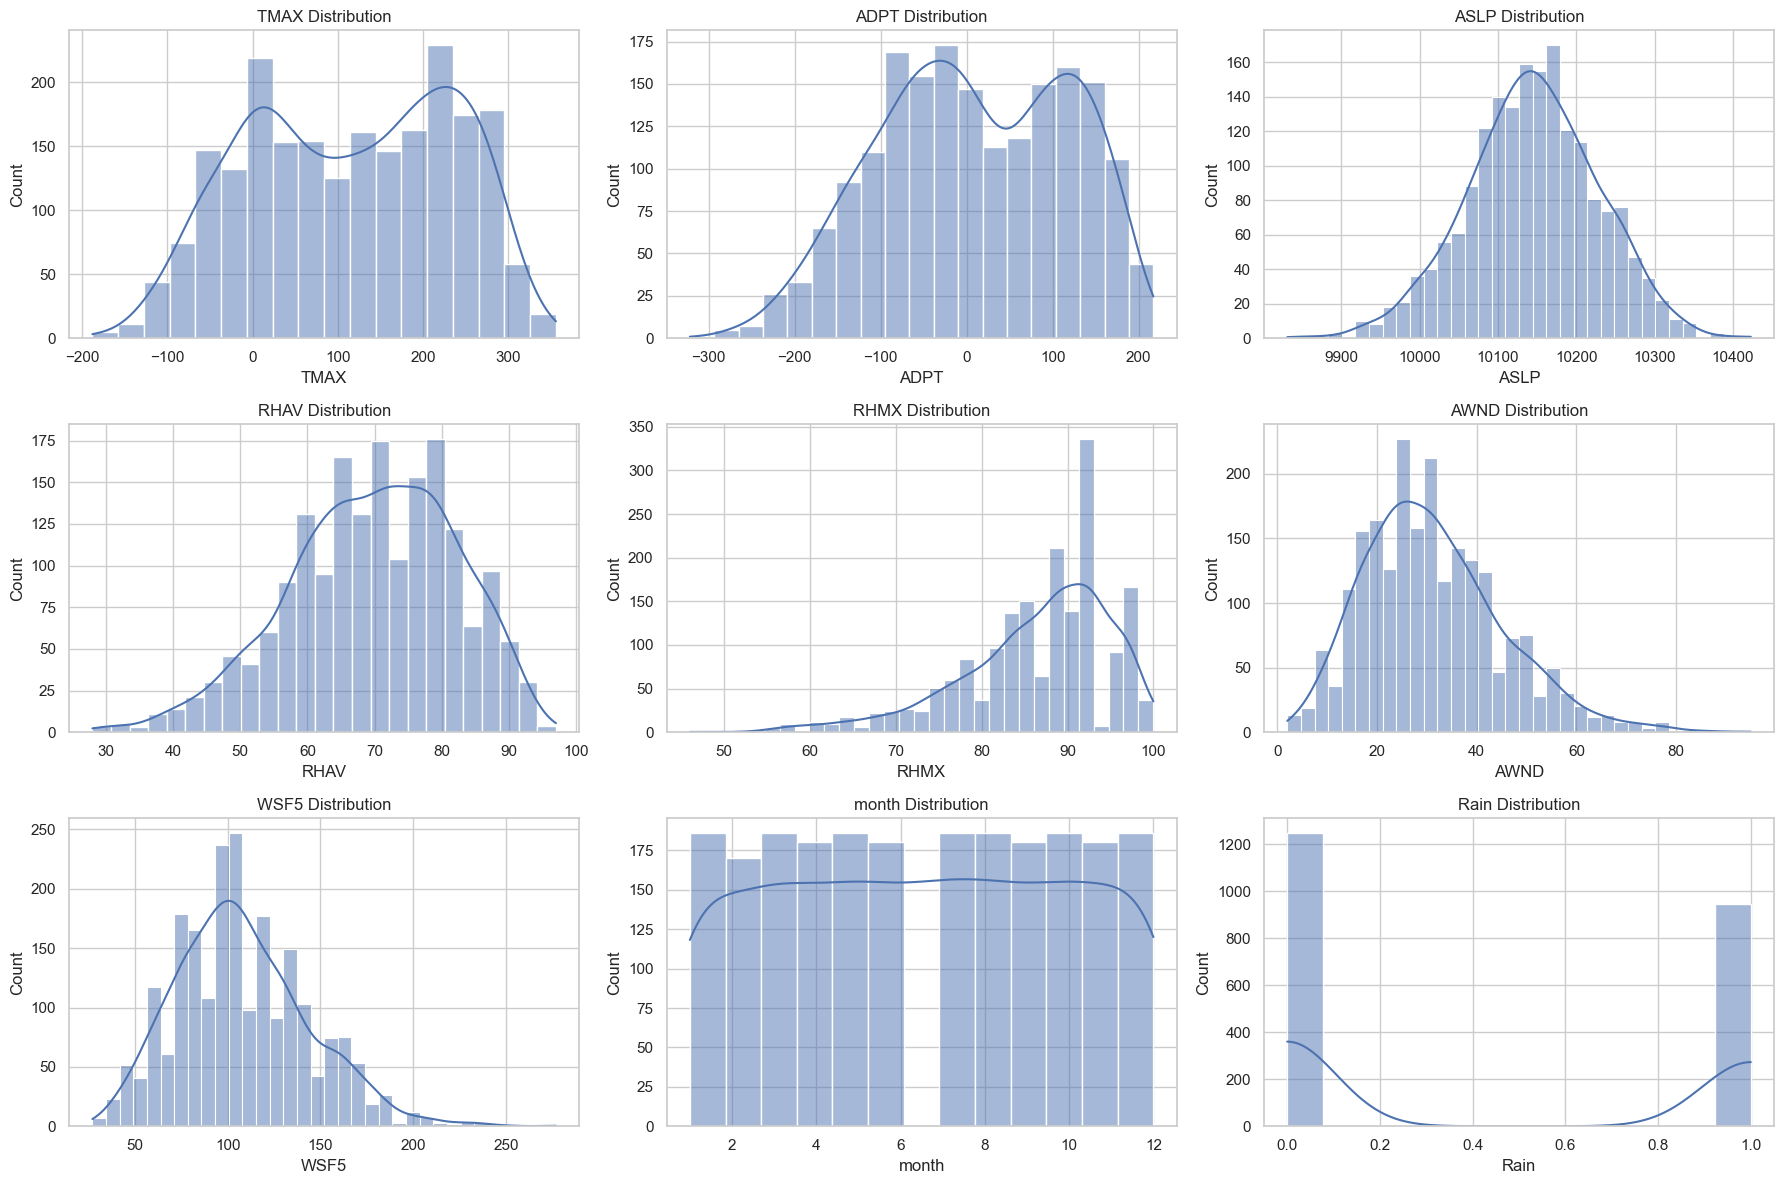

In [34]:
fig, axes = plt.subplots(
    len(numeric_cols)//3,
    3,
    figsize=(18, 12)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(col + ' Distribution')

plt.tight_layout()
plt.show()

# Relación entre variables meteorológicas y lluvia

Con el objetivo de evaluar la capacidad predictiva de las variables seleccionadas, se analizaron sus distribuciones condicionadas por la variable objetivo (`Rain`).

Para ello se utilizaron gráficos de densidad Kernel (KDE), los cuales permiten comparar el comportamiento estadístico de cada feature entre días con lluvia y sin lluvia.

## Variables de humedad

Las variables relacionadas con humedad (`RHAV`, `RHMX`) muestran la separación más clara entre clases.

Los días lluviosos presentan distribuciones desplazadas hacia valores más altos de humedad relativa, especialmente en `RHMX`, donde los eventos de lluvia se concentran cerca de valores extremos.

Este comportamiento resulta consistente con fenómenos meteorológicos reales y sugiere una fuerte capacidad predictiva de estas variables.

## Presión atmosférica

La presión atmosférica (`ASLP`) exhibe una relación inversa con la ocurrencia de lluvia.

Los días lluviosos tienden a concentrarse en valores más bajos de presión, comportamiento asociado típicamente a sistemas de baja presión atmosférica y condiciones inestables.

## Variables de viento

Las variables asociadas al viento (`AWND`, `WSF5`) presentan diferencias moderadas entre clases.

Aunque la separación no resulta tan marcada como en las variables de humedad, puede observarse una tendencia hacia mayores velocidades de viento durante eventos lluviosos.

## Punto de rocío

La variable `ADPT` presenta un comportamiento multimodal y diferencias no lineales entre clases, lo cual sugiere la presencia de patrones climáticos complejos.

Este tipo de comportamiento representa una señal favorable para modelos capaces de capturar relaciones no lineales.

## Implicancias para modelado

Los resultados obtenidos indican que el dataset contiene señales predictivas relevantes para la clasificación de eventos de lluvia.

Además, la existencia de relaciones parcialmente no lineales sugiere que modelos basados en árboles y métodos de ensamble podrían adaptarse particularmente bien a este problema.

In [19]:
key_features = [
    'RHAV',
    'RHMX',
    'ASLP',
    'AWND',
    'WSF5',
    'ADPT'
]

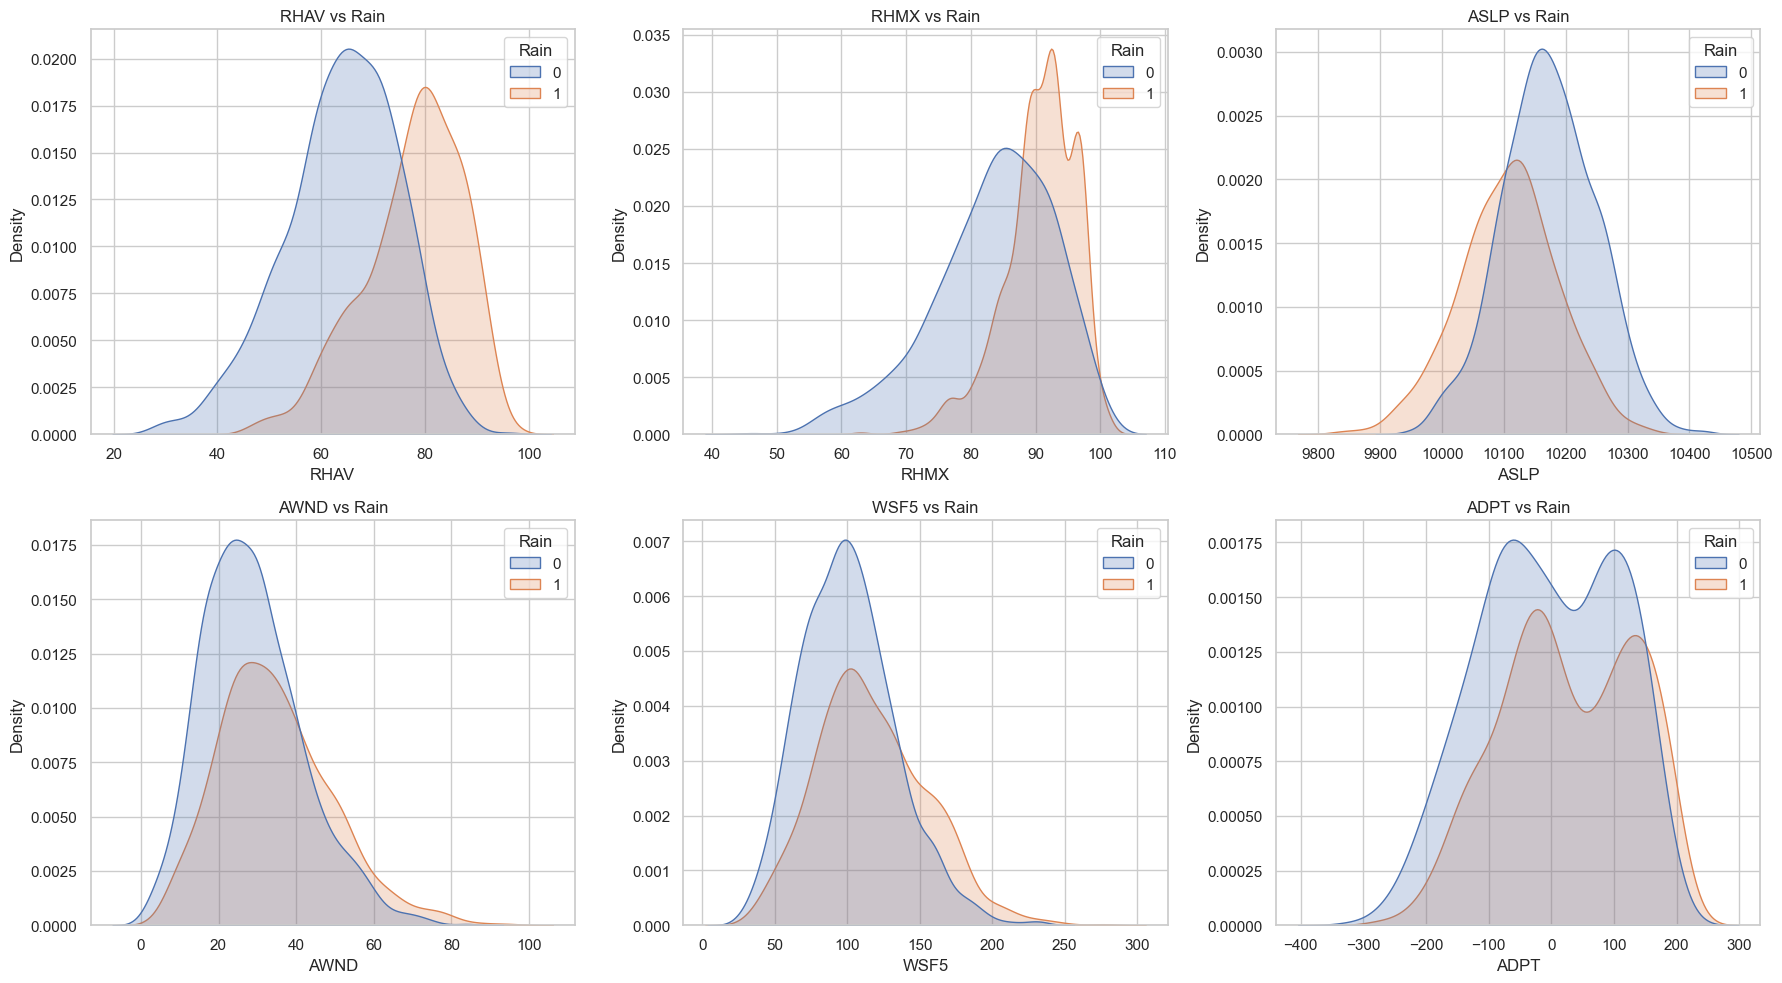

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, col in enumerate(key_features):

    sns.kdeplot(
        data=df,
        x=col,
        hue='Rain',
        fill=True,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs Rain')

plt.tight_layout()
plt.show()

# Análisis multivariado mediante Pairplot

Con el objetivo de analizar simultáneamente las relaciones entre variables meteorológicas y la separación entre clases, se construyó un pairplot utilizando las features más representativas del sistema climático.

Este tipo de visualización permite observar:

- relaciones entre variables,
- posibles patrones no lineales,
- agrupamientos,
- y comportamiento conjunto respecto a la variable objetivo (`Rain`).

## Relaciones observadas

### Humedad y punto de rocío

Las variables `RHAV` y `ADPT` presentan una relación positiva clara, consistente con el comportamiento físico esperado entre humedad atmosférica y punto de rocío.

Además, los eventos de lluvia tienden a concentrarse en regiones de alta humedad y mayores valores de punto de rocío.

### Humedad y presión atmosférica

Se observa una relación inversa entre humedad relativa y presión atmosférica (`ASLP`), donde los eventos lluviosos aparecen principalmente asociados a:

- alta humedad,
- y menores niveles de presión.

Este comportamiento coincide con sistemas atmosféricos inestables típicamente asociados a precipitaciones.

### Variables de viento

Las variables relacionadas con viento muestran una mayor dispersión y relaciones menos definidas, aunque continúan aportando información complementaria para distinguir eventos de lluvia.

## Comportamiento no lineal

El análisis multivariado evidencia que las clases no presentan una separación lineal simple.

Asimismo, variables como `ADPT` exhiben comportamientos multimodales y distribuciones complejas, lo cual sugiere la presencia de relaciones no lineales dentro del sistema climático.

## Implicancias para modelado

Los patrones observados sugieren que modelos capaces de capturar relaciones no lineales podrían adaptarse particularmente bien a este problema.

Entre los modelos potencialmente adecuados se destacan:

- Random Forest,
- Gradient Boosting,
- XGBoost,
- SVM con kernels,
- y métodos de ensamble.

Este comportamiento también justifica la utilización de validación estratificada y métricas robustas para clasificación binaria.

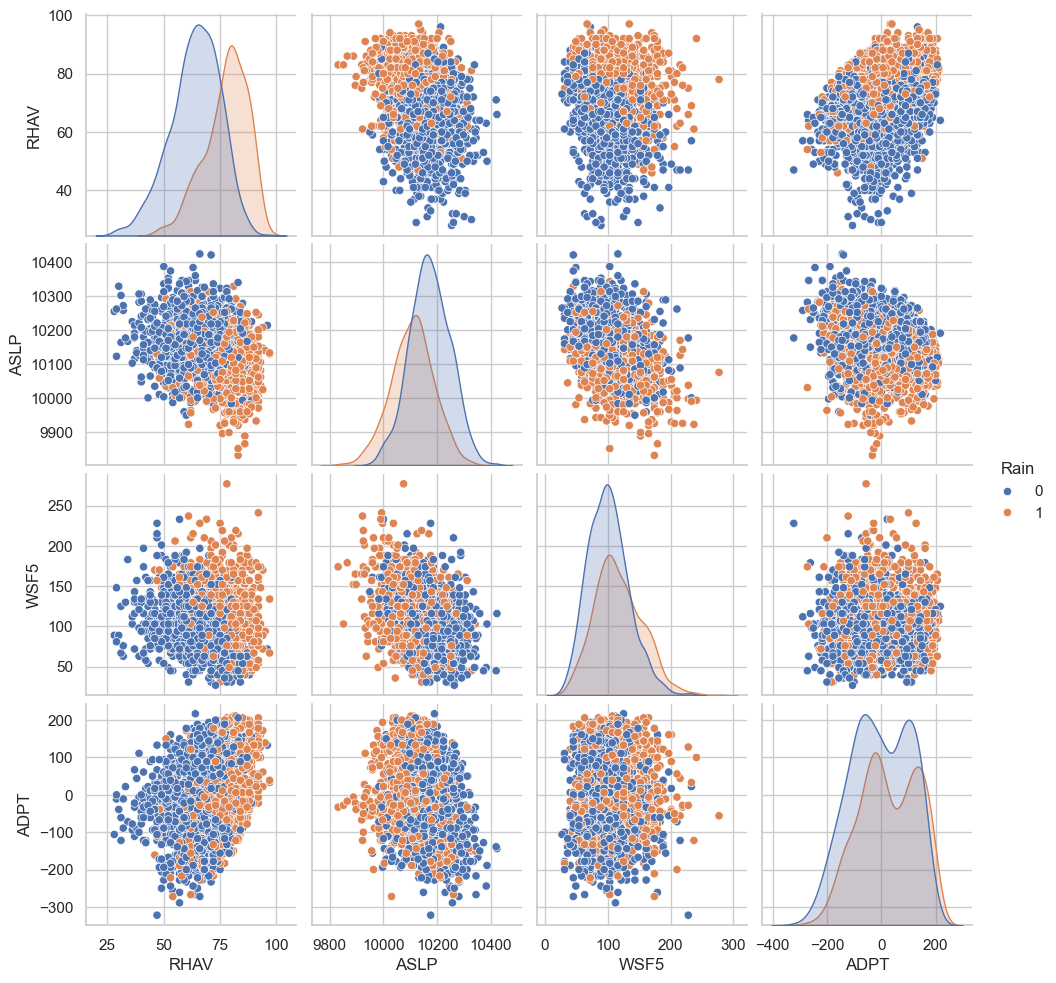

In [33]:
pair_features = [
    'RHAV',
    'ASLP',
    'WSF5',
    'ADPT',
    'Rain'
]

sns.pairplot(
    df[pair_features],
    hue='Rain'
)

plt.show()

# Estacionalidad y variables temporales

Debido a la naturaleza climática del problema, resulta importante analizar la posible existencia de patrones estacionales asociados a la ocurrencia de lluvia.

Para ello se evaluó la probabilidad promedio de lluvia según el mes del año.

## Estacionalidad observada

El análisis muestra variaciones claras en la frecuencia de lluvia a lo largo del año, indicando la presencia de comportamiento estacional dentro del sistema climático.

Se observan meses con mayor probabilidad de precipitación, mientras que otros presentan condiciones considerablemente más secas.

Estos patrones sugieren que la información temporal puede aportar capacidad predictiva adicional para el problema de clasificación.


In [ ]:
monthly_rain = df.groupby('month')['Rain'].mean()

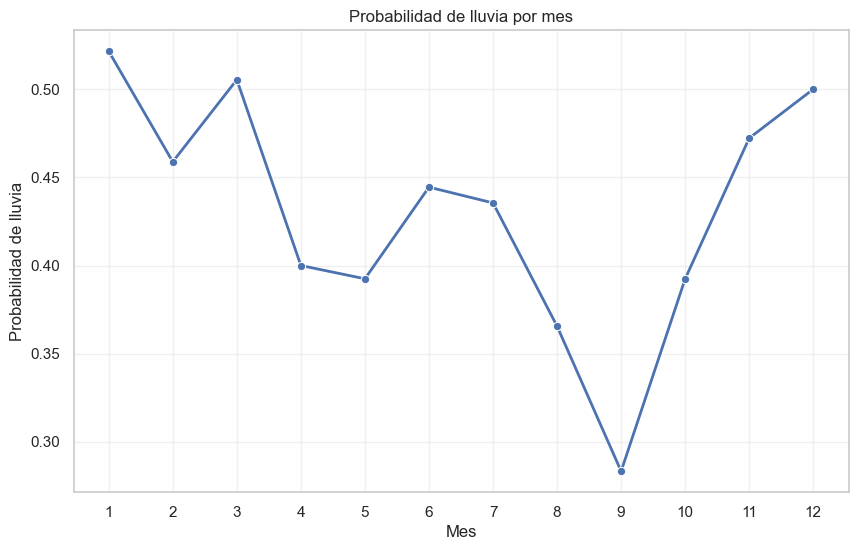

In [37]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=monthly_rain.index,
    y=monthly_rain.values,
    marker='o',
    linewidth=2
)

plt.xticks(range(1,13))

plt.title('Probabilidad de lluvia por mes')
plt.xlabel('Mes')
plt.ylabel('Probabilidad de lluvia')

plt.grid(alpha=0.3)

plt.show()